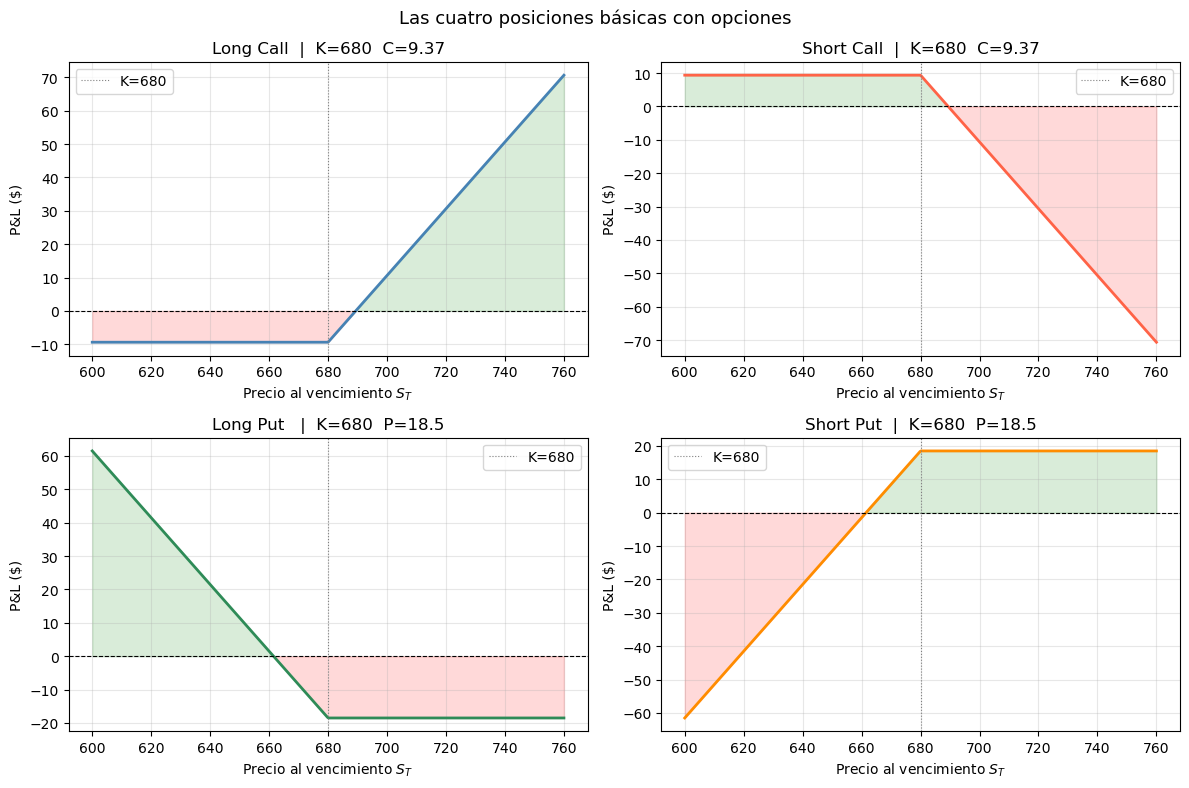

In [1]:
import numpy as np
import matplotlib.pyplot as plt

S_range = np.linspace(600, 760, 500)   # rango de precios al vencimiento
K = 680
C = 9.37    # prima del call
P = 18.50   # prima del put

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()

In [2]:
def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.

    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)

    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))

    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)

        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl

    return total


def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

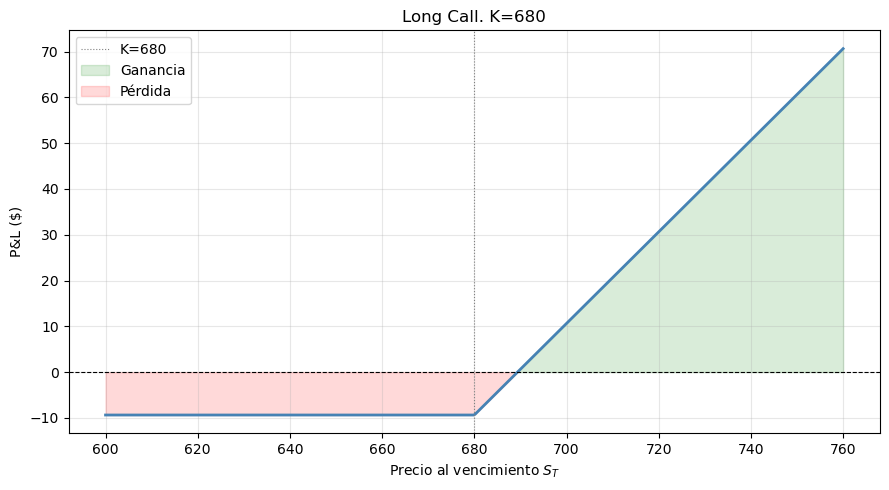

In [3]:
legs_call = [
    {'tipo': 'call', 'K': 680, 'prima': 9.37, 'posicion': +1}
]

pnl = payoff_estrategia(S_range, legs_call)
graficar_estrategia(S_range, pnl, 'Long Call. K=680',
                    K_lines=[(680, 'K=680')])

Griega       Valor  Interpretación
delta       0.4076  Si SPY sube $1, el call sube $0.4076
gamma       0.0118  Delta cambia0.0118 por cada $1 de SPY
vega        0.7569  Si IV sube 1%, el call sube $0.7569
theta      -0.2363  El call pierde $0.2363 por día
rho         0.2237  Si tasas suben 1%, el call cambia $0.2237


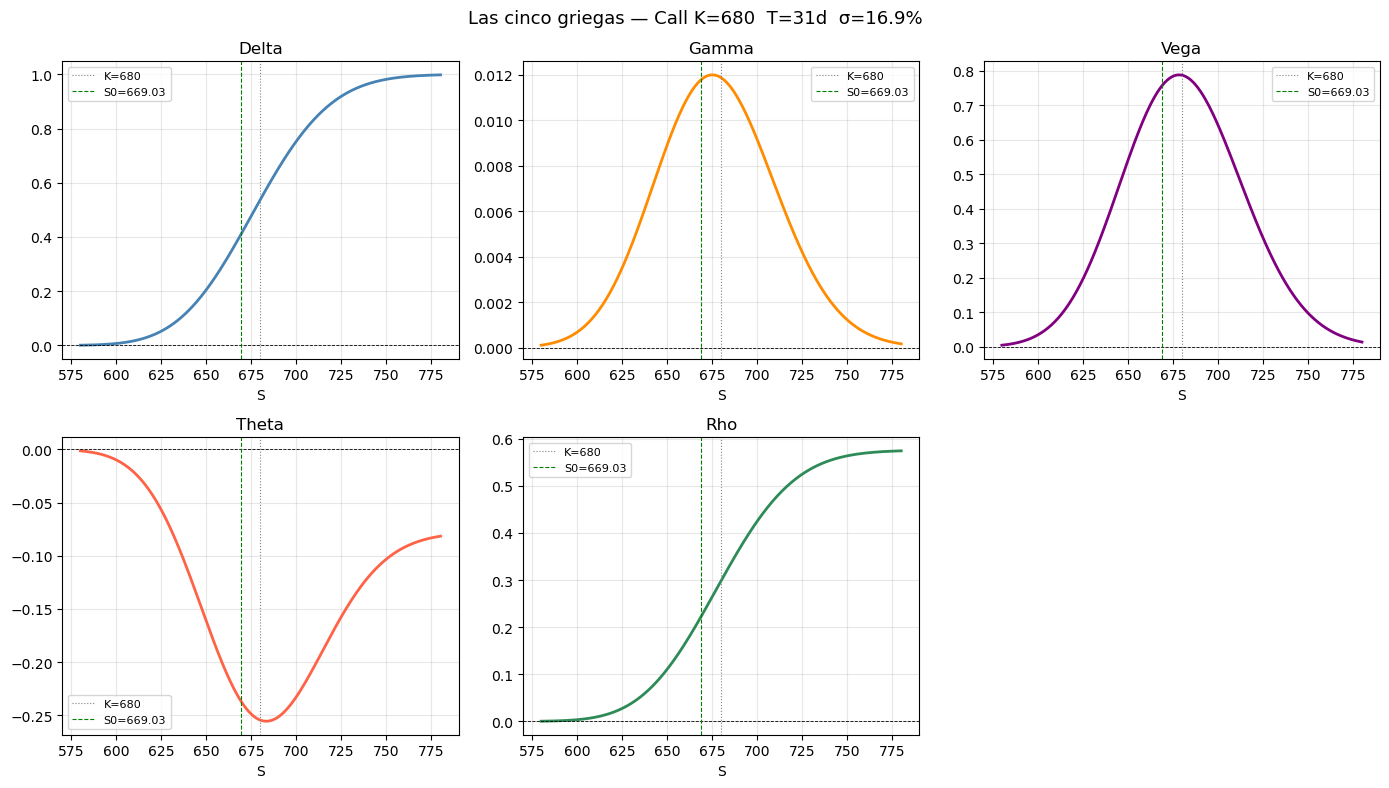

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def greeks(S, K, r, T, sigma, option='call'):
    if T <= 0 or sigma <= 0:
        return {k: 0 for k in ['delta','gamma','vega','theta','rho']}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
    vega  = S*norm.pdf(d1)*np.sqrt(T) / 100
    if option == 'call':
        delta = norm.cdf(d1)
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
        rho   =  K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta, 'rho': rho}

# Parámetros
S0, K, r, T, sigma = 669.03, 680, 0.042, 31/365, 0.1687

# Griegas en el punto actual
g = greeks(S0, K, r, T, sigma, 'call')
print(f"{'Griega':<8}{'Valor':>10}  Interpretación")
print(f"{'delta':<8}{g['delta']:>10.4f}  Si SPY sube $1, el call sube ${g['delta']:.4f}")
print(f"{'gamma':<8}{g['gamma']:>10.4f}  Delta cambia{g['gamma']:.4f} por cada $1 de SPY")
print(f"{'vega':<8}{g['vega']:>10.4f}  Si IV sube 1%, el call sube ${g['vega']:.4f}")
print(f"{'theta':<8}{g['theta']:>10.4f}  El call pierde ${abs(g['theta']):.4f} por día")
print(f"{'rho':<8}{g['rho']:>10.4f}  Si tasas suben 1%, el call cambia ${g['rho']:.4f}")

# Plot de las 5 griegas vs. precio
S_range  = np.linspace(580, 780, 300)
metricas = ['delta', 'gamma', 'vega', 'theta', 'rho']
colores  = ['steelblue', 'darkorange', 'purple', 'tomato', 'seagreen']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (m, c) in enumerate(zip(metricas, colores)):
    vals = [greeks(s, K, r, T, sigma, 'call')[m] for s in S_range]
    axes[i].plot(S_range, vals, color=c, linewidth=2)
    axes[i].axhline(0,  color='black', linewidth=0.6, linestyle='--')
    axes[i].axvline(K,  color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    axes[i].axvline(S0, color='green', linewidth=0.8, linestyle='--', label=f'S0={S0}')
    axes[i].set_title(m.capitalize())
    axes[i].set_xlabel('S')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[5].axis('off')
plt.suptitle(f'Las cinco griegas — Call K={K}  T={round(T*365)}d  σ={sigma:.1%}', fontsize=13)
plt.tight_layout()
plt.show()

### Actividad

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [7]:
# 1. OBTENCIÓN DE DATOS REALES

TICKER = "SPY"
EXPIRACION  = "2026-04-17"
 
spy = yf.Ticker(TICKER)
 
S0 = spy.history(period="1d")["Close"].iloc[-1]
print(f"Precio spot SPY (S0): ${S0:.2f}")
 
chain = spy.option_chain(EXPIRACION)
calls = chain.calls.copy()
puts = chain.puts.copy()

calls["mid"] = (calls["bid"] + calls["ask"]) / 2
puts["mid"] = (puts["bid"]  + puts["ask"])  / 2
 
print(f"\nVencimiento: {EXPIRACION}")
print(f"Calls disponibles (primeras filas):")
print(calls[["strike","bid","ask","mid","impliedVolatility"]].head(10).to_string(index=False))
print(f"\nPuts disponibles (primeras filas):")
print(puts[["strike","bid","ask","mid","impliedVolatility"]].head(10).to_string(index=False))

Precio spot SPY (S0): $679.91

Vencimiento: 2026-04-17
Calls disponibles (primeras filas):
 strike    bid    ask     mid  impliedVolatility
  300.0 378.41 381.22 379.815           2.693851
  305.0 373.41 376.22 374.815           2.644046
  310.0 368.42 371.23 369.825           2.598148
  325.0 353.43 356.24 354.835           2.458500
  330.0 348.44 351.25 349.845           2.415043
  335.0 343.44 346.25 344.845           2.369633
  345.0 333.45 336.26 334.855           2.283207
  350.0   0.00   0.00   0.000           0.000010
  355.0 323.46 326.27 324.865           2.199223
  360.0 318.47 321.28 319.875           2.159184

Puts disponibles (primeras filas):
 strike  bid  ask   mid  impliedVolatility
  300.0  0.0 0.01 0.005           1.562502
  305.0  0.0 0.01 0.005           1.531252
  310.0  0.0 0.01 0.005           1.500002
  315.0  0.0 0.01 0.005           1.468753
  320.0  0.0 0.01 0.005           1.437503
  325.0  0.0 0.01 0.005           1.406253
  330.0  0.0 0.01 0.005          

In [8]:
# 2. SELECCIÓN DE STRIKES

atm_strike = calls.iloc[(calls["strike"] - S0).abs().argsort()[:1]]["strike"].values[0]
 
otm_call_strike = calls.iloc[(calls["strike"] - S0 * 1.025).abs().argsort()[:1]]["strike"].values[0]

otm_put_strike = puts.iloc[(puts["strike"] - S0 * 0.975).abs().argsort()[:1]]["strike"].values[0]

short_put_strike = puts.iloc[(puts["strike"] - S0 * 0.960).abs().argsort()[:1]]["strike"].values[0]
 
def get_mid(df, strike):
    row = df[df["strike"] == strike]
    if row.empty:
        raise ValueError(f"Strike {strike} no encontrado")
    return round(row["mid"].values[0], 2)
 
# Primas mid reales
C_atm = get_mid(calls, atm_strike)      
P_atm = get_mid(puts,  atm_strike)      
C_otm = get_mid(calls, otm_call_strike)  
P_otm = get_mid(puts,  otm_put_strike)   
P_short = get_mid(puts,  short_put_strike) 
 
print(f"\n{'='*55}")
print(f"STRIKES Y PRIMAS SELECCIONADOS")
print(f"{'='*55}")
print(f"ATM strike          : {atm_strike}    (S0 ≈ {S0:.2f})")
print(f"OTM call strike     : {otm_call_strike}")
print(f"OTM put strike      : {otm_put_strike}")
print(f"Short put strike    : {short_put_strike}")
print(f"\nCall ATM mid        : ${C_atm}")
print(f"Put  ATM mid        : ${P_atm}")
print(f"Call OTM mid        : ${C_otm}")
print(f"Put  OTM mid        : ${P_otm}")
print(f"Put  short mid      : ${P_short}")


STRIKES Y PRIMAS SELECCIONADOS
ATM strike          : 680.0    (S0 ≈ 679.91)
OTM call strike     : 697.0
OTM put strike      : 663.0
Short put strike    : 653.0

Call ATM mid        : $6.07
Put  ATM mid        : $5.94
Call OTM mid        : $0.44
Put  OTM mid        : $1.82
Put  short mid      : $0.9


In [9]:
# 3. FUNCIONES

def payoff_estrategia(S_range, legs):
    """
    Calcula el P&L neto de una estrategia con cualquier número de legs.
 
    Parámetros:
    -----------
    S_range : array de precios al vencimiento
    legs    : lista de dicts, cada uno con:
        tipo     : 'call' o 'put'
        K        : strike
        prima    : prima pagada (+) o cobrada (-)
        posicion : +1 (long) o -1 (short)
 
    Retorna:
    --------
    Array de P&L neto para cada precio en S_range
    """
    total = np.zeros(len(S_range))
 
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
 
        pnl    = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
 
    return total
 
 
def graficar_estrategia(S_range, pnl, titulo, K_lines=None):
    """Grafica el P&L de una estrategia con formato estándar."""
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8,
                        linestyle=':', label=label)
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0),
                     alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0),
                     alpha=0.15, color='red',   label='Pérdida')
    plt.xlabel('Precio al vencimiento $S_T$')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 

S_range = np.linspace(S0 * 0.90, S0 * 1.10, 500)


LONG STRADDLE  |  K=680.0  |  Venc. 2026-04-17
  Long Call  K=680.0  prima=$6.07
  Long Put   K=680.0  prima=$5.94
  Prima neta (costo)  : -$12.01
  Pérdida máxima      : -$12.01  (si ST = 680.0)
  Ganancia máxima     : Ilimitada
  Break-even inferior : $667.99
  Break-even superior : $692.01


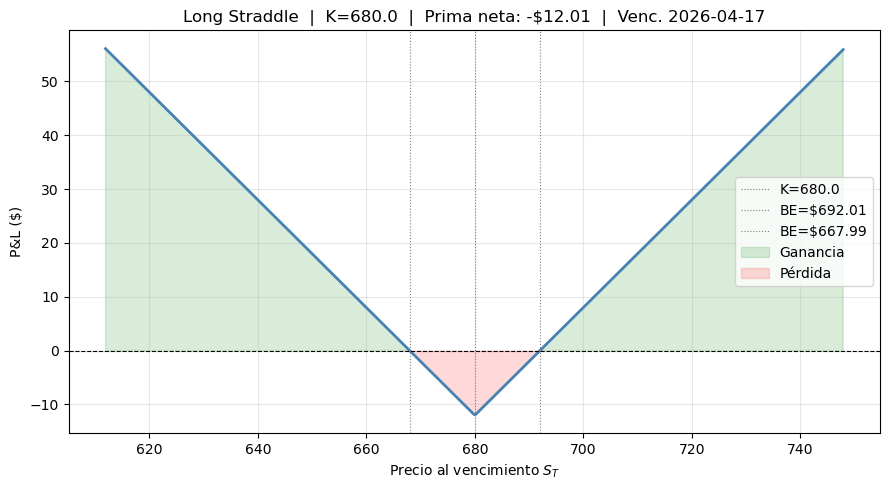

In [10]:
# 4. ESTRATEGIA 1 — LONG STRADDLE
 
prima_straddle = C_atm + P_atm
be_straddle_up = atm_strike + prima_straddle
be_straddle_down = atm_strike - prima_straddle
 
print(f"\n{'='*55}")
print(f"LONG STRADDLE  |  K={atm_strike}  |  Venc. {EXPIRACION}")
print(f"{'='*55}")
print(f"  Long Call  K={atm_strike}  prima=${C_atm}")
print(f"  Long Put   K={atm_strike}  prima=${P_atm}")
print(f"  Prima neta (costo)  : -${prima_straddle:.2f}")
print(f"  Pérdida máxima      : -${prima_straddle:.2f}  (si ST = {atm_strike})")
print(f"  Ganancia máxima     : Ilimitada")
print(f"  Break-even inferior : ${be_straddle_down:.2f}")
print(f"  Break-even superior : ${be_straddle_up:.2f}")
 
legs_straddle = [
    {'tipo': 'call', 'K': atm_strike, 'prima': C_atm, 'posicion': +1},
    {'tipo': 'put',  'K': atm_strike, 'prima': P_atm, 'posicion': +1},
]
pnl_straddle = payoff_estrategia(S_range, legs_straddle)
graficar_estrategia(
    S_range, pnl_straddle,
    f'Long Straddle  |  K={atm_strike}  |  Prima neta: -${prima_straddle:.2f}  |  Venc. {EXPIRACION}',
    K_lines=[
        (atm_strike,       f'K={atm_strike}'),
        (be_straddle_up,   f'BE=${be_straddle_up:.2f}'),
        (be_straddle_down, f'BE=${be_straddle_down:.2f}'),
    ]
)


LONG STRANGLE  |  Kc=697.0  Kp=663.0  |  Venc. 2026-04-17
  Long Call  K=697.0  prima=$0.44
  Long Put   K=663.0   prima=$1.82
  Prima neta (costo)  : -$2.26
  Pérdida máxima      : -$2.26  (si 663.0 ≤ ST ≤ 697.0)
  Ganancia máxima     : Ilimitada
  Break-even inferior : $660.74
  Break-even superior : $699.26


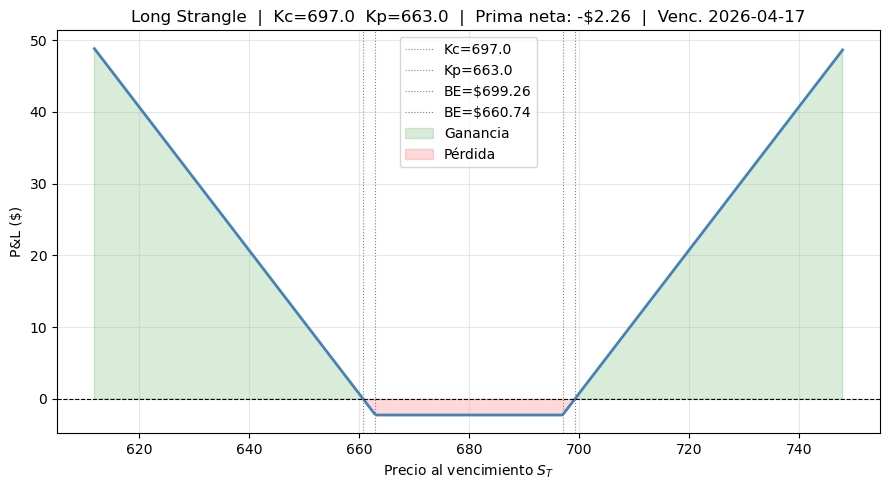

In [11]:
# 5. ESTRATEGIA 2 — LONG STRANGLE

prima_strangle = C_otm + P_otm
be_strangle_up = otm_call_strike + prima_strangle
be_strangle_down = otm_put_strike  - prima_strangle
 
print(f"\n{'='*55}")
print(f"LONG STRANGLE  |  Kc={otm_call_strike}  Kp={otm_put_strike}  |  Venc. {EXPIRACION}")
print(f"{'='*55}")
print(f"  Long Call  K={otm_call_strike}  prima=${C_otm}")
print(f"  Long Put   K={otm_put_strike}   prima=${P_otm}")
print(f"  Prima neta (costo)  : -${prima_strangle:.2f}")
print(f"  Pérdida máxima      : -${prima_strangle:.2f}  (si {otm_put_strike} ≤ ST ≤ {otm_call_strike})")
print(f"  Ganancia máxima     : Ilimitada")
print(f"  Break-even inferior : ${be_strangle_down:.2f}")
print(f"  Break-even superior : ${be_strangle_up:.2f}")
 
legs_strangle = [
    {'tipo': 'call', 'K': otm_call_strike, 'prima': C_otm, 'posicion': +1},
    {'tipo': 'put',  'K': otm_put_strike,  'prima': P_otm, 'posicion': +1},
]
pnl_strangle = payoff_estrategia(S_range, legs_strangle)
graficar_estrategia(
    S_range, pnl_strangle,
    f'Long Strangle  |  Kc={otm_call_strike}  Kp={otm_put_strike}  |  Prima neta: -${prima_strangle:.2f}  |  Venc. {EXPIRACION}',
    K_lines=[
        (otm_call_strike,  f'Kc={otm_call_strike}'),
        (otm_put_strike,   f'Kp={otm_put_strike}'),
        (be_strangle_up,   f'BE=${be_strangle_up:.2f}'),
        (be_strangle_down, f'BE=${be_strangle_down:.2f}'),
    ]
)


BULL CALL SPREAD  |  Kl=680.0  Ks=697.0  |  Venc. 2026-04-17
  Long Call  K=680.0   prima=$6.07
  Short Call K=697.0  prima=$0.44
  Prima neta (débito)  : -$5.63
  Pérdida máxima       : -$5.63  (si ST ≤ 680.0)
  Ganancia máxima      : +$11.37  (si ST ≥ 697.0)
  Break-even           : $685.63


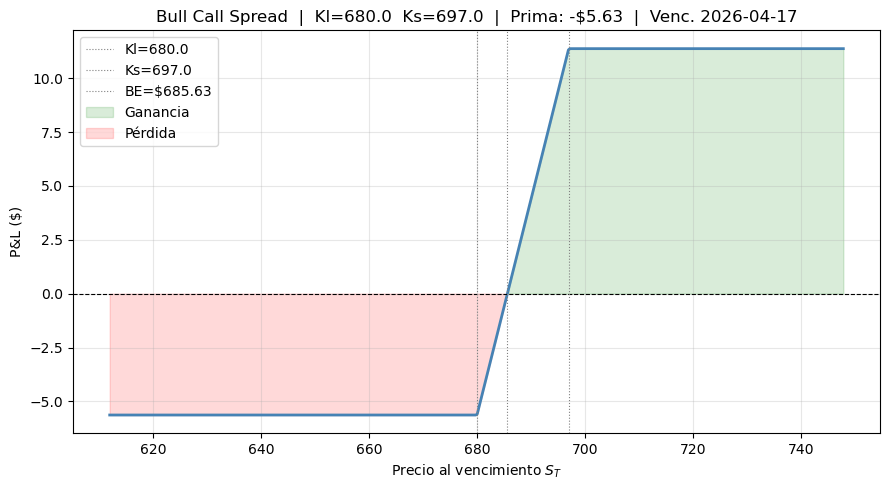

In [12]:
# 6. ESTRATEGIA 3 — BULL CALL SPREAD
 
K_bc_long = atm_strike
K_bc_short = otm_call_strike
prima_bc = C_atm - C_otm       
ganancia_max_bc = (K_bc_short - K_bc_long) - prima_bc
be_bc = K_bc_long + prima_bc
 
print(f"\n{'='*55}")
print(f"BULL CALL SPREAD  |  Kl={K_bc_long}  Ks={K_bc_short}  |  Venc. {EXPIRACION}")
print(f"{'='*55}")
print(f"  Long Call  K={K_bc_long}   prima=${C_atm}")
print(f"  Short Call K={K_bc_short}  prima=${C_otm}")
print(f"  Prima neta (débito)  : -${prima_bc:.2f}")
print(f"  Pérdida máxima       : -${prima_bc:.2f}  (si ST ≤ {K_bc_long})")
print(f"  Ganancia máxima      : +${ganancia_max_bc:.2f}  (si ST ≥ {K_bc_short})")
print(f"  Break-even           : ${be_bc:.2f}")
 
legs_bc = [
    {'tipo': 'call', 'K': K_bc_long,  'prima': C_atm, 'posicion': +1},
    {'tipo': 'call', 'K': K_bc_short, 'prima': C_otm, 'posicion': -1},
]
pnl_bc = payoff_estrategia(S_range, legs_bc)
graficar_estrategia(
    S_range, pnl_bc,
    f'Bull Call Spread  |  Kl={K_bc_long}  Ks={K_bc_short}  |  Prima: -${prima_bc:.2f}  |  Venc. {EXPIRACION}',
    K_lines=[
        (K_bc_long,  f'Kl={K_bc_long}'),
        (K_bc_short, f'Ks={K_bc_short}'),
        (be_bc,      f'BE=${be_bc:.2f}'),
    ]
)


BEAR PUT SPREAD  |  Kl=663.0  Ks=653.0  |  Venc. 2026-04-17
  Long Put   K=663.0   prima=$1.82
  Short Put  K=653.0  prima=$0.9
  Prima neta (débito)  : -$0.92
  Pérdida máxima       : -$0.92  (si ST ≥ 663.0)
  Ganancia máxima      : +$9.08  (si ST ≤ 653.0)
  Break-even           : $662.08


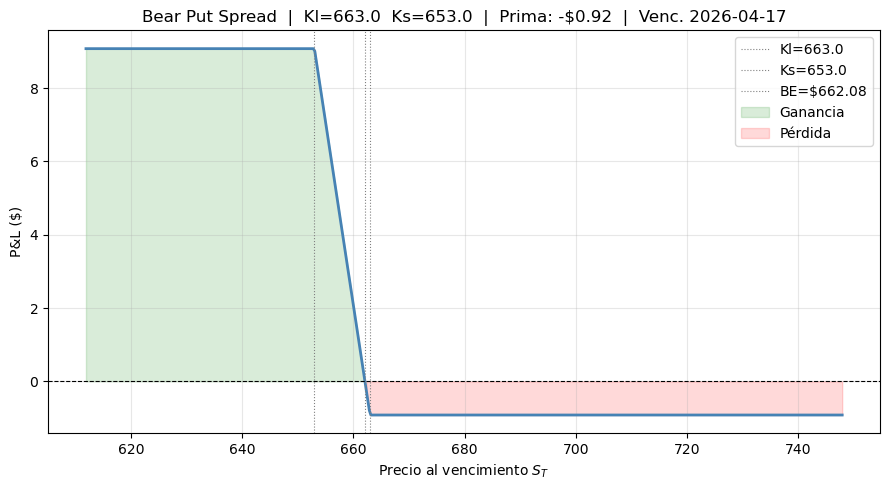

In [13]:
# 7. ESTRATEGIA 4 — BEAR PUT SPREAD
 
K_bp_long = otm_put_strike   # put largo (strike más alto)
K_bp_short = short_put_strike  # put corto (strike más bajo)
prima_bp = P_otm - P_short   # débito neto
ganancia_max_bp = (K_bp_long - K_bp_short) - prima_bp
be_bp = K_bp_long - prima_bp
 
print(f"\n{'='*55}")
print(f"BEAR PUT SPREAD  |  Kl={K_bp_long}  Ks={K_bp_short}  |  Venc. {EXPIRACION}")
print(f"{'='*55}")
print(f"  Long Put   K={K_bp_long}   prima=${P_otm}")
print(f"  Short Put  K={K_bp_short}  prima=${P_short}")
print(f"  Prima neta (débito)  : -${prima_bp:.2f}")
print(f"  Pérdida máxima       : -${prima_bp:.2f}  (si ST ≥ {K_bp_long})")
print(f"  Ganancia máxima      : +${ganancia_max_bp:.2f}  (si ST ≤ {K_bp_short})")
print(f"  Break-even           : ${be_bp:.2f}")
 
legs_bp = [
    {'tipo': 'put', 'K': K_bp_long,  'prima': P_otm,   'posicion': +1},
    {'tipo': 'put', 'K': K_bp_short, 'prima': P_short,  'posicion': -1},
]
pnl_bp = payoff_estrategia(S_range, legs_bp)
graficar_estrategia(
    S_range, pnl_bp,
    f'Bear Put Spread  |  Kl={K_bp_long}  Ks={K_bp_short}  |  Prima: -${prima_bp:.2f}  |  Venc. {EXPIRACION}',
    K_lines=[
        (K_bp_long,  f'Kl={K_bp_long}'),
        (K_bp_short, f'Ks={K_bp_short}'),
        (be_bp,      f'BE=${be_bp:.2f}'),
    ]
)

In [14]:
# 8. TABLA RESUMEN
 
print(f"\n{'='*75}")
print(f"TABLA RESUMEN — ESTRATEGIAS SPY  |  Vencimiento {EXPIRACION}  |  S0=${S0:.2f}")
print(f"{'='*75}")
print(f"{'Estrategia':<22} {'Prima neta':>12} {'Gan. máx.':>12} {'Pérd. máx.':>12} {'Break-even(s)'}")
print(f"{'-'*75}")
 
print(f"{'Long Straddle':<22} {'- $'+f'{prima_straddle:.2f}':>12} {'Ilimitada':>12} {'- $'+f'{prima_straddle:.2f}':>12}  ${be_straddle_down:.2f} / ${be_straddle_up:.2f}")
print(f"{'Long Strangle':<22} {'- $'+f'{prima_strangle:.2f}':>12} {'Ilimitada':>12} {'- $'+f'{prima_strangle:.2f}':>12}  ${be_strangle_down:.2f} / ${be_strangle_up:.2f}")
print(f"{'Bull Call Spread':<22} {'- $'+f'{prima_bc:.2f}':>12} {'+ $'+f'{ganancia_max_bc:.2f}':>12} {'- $'+f'{prima_bc:.2f}':>12}  ${be_bc:.2f}")
print(f"{'Bear Put Spread':<22} {'- $'+f'{prima_bp:.2f}':>12} {'+ $'+f'{ganancia_max_bp:.2f}':>12} {'- $'+f'{prima_bp:.2f}':>12}  ${be_bp:.2f}")
print(f"{'='*75}")


TABLA RESUMEN — ESTRATEGIAS SPY  |  Vencimiento 2026-04-17  |  S0=$679.91
Estrategia               Prima neta    Gan. máx.   Pérd. máx. Break-even(s)
---------------------------------------------------------------------------
Long Straddle              - $12.01    Ilimitada     - $12.01  $667.99 / $692.01
Long Strangle               - $2.26    Ilimitada      - $2.26  $660.74 / $699.26
Bull Call Spread            - $5.63     + $11.37      - $5.63  $685.63
Bear Put Spread             - $0.92      + $9.08      - $0.92  $662.08


#### Preguntas

- 1.- Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?

El Long Straddle y el Long Strangle son los que están más cerca de su zona de máxima pérdida. Ambas estrategias pierden el máximo cuando SPY termina exactamente en el strike, y con S0 = 679.91 estamos casi encima del strike ATM de 680. Esto significa que si SPY no se mueve nada de aquí al vencimiento, se perderia prácticamente toda la prima pagada. La visión de mercado que expresa es que apostaste a que el mercado se movería mucho, pero si el mercado se queda quieto, la estrategia falla por completo.

- 2.- Compara el costo total del long straddle vs. el long strangle que construiste. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?

Straddle cuesta 12.01, el strangle cuesta 2.26, el strangle es 9.75 más barato. Sin embargo, el straddle empieza a ganar si SPY se mueve más de 12.01 (break-evens en 667.99 y 692.01). El strangle necesita que SPY se mueva más de 19.26 hacia arriba (hasta 699.26) o 19.17 hacia abajo (hasta 660.74).

- 3.- Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.

No necesariamente. Cuando hay un evento importante, la volatilidad implícita ya sube antes del evento porque todos esperan movimiento. Eso infla el precio de las opciones. Al comprar el straddle en ese momento, estás pagando una prima elevada. Cuando el evento pasa, aunque el precio de SPY se mueva, la volatilidad implicita cae bruscamente, y esa caída derrumba el valor de tus opciones. El resultado es que podrías perder dinero incluso si SPY se mueve en la dirección correcta. El straddle es mejor comprarlo antes de que la volatilidad implicita suba, no cuando ya está inflada.

- 4.- El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.

Existen dos razones principales por las que un trader aceptaría voluntariamente limitar su ganancia. La primera es el costo: un long call simple sobre K=680 cuesta 6.07, mientras que el bull call spread solo cuesta 5.63, ya que la venta del call K=697 financia parte de la compra, reduciendo el capital en riesgo. La segunda es que al bajar el costo, el break-even se reduce a 685.63 en lugar de 686.07, y además no se necesita que SPY suba indefinidamente para obtener una buena ganancia; con que llegue a 697 ya se captura la ganancia máxima de 11.37, lo que hace al spread una estrategia más eficiente cuando la visión de mercado es alcista moderada, no extrema.

- 5.- Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?

La decisión depende de varios factores. En general, conviene considerar cerrar la posición anticipadamente tomando en cuenta lo siguiente: si queda mucho tiempo al vencimiento, el spread todavía no vale su máximo teórico porque el valor temporal sigue presente y esperar sería riesgoso si SPY revierte; si el spread ya vale 14–15 de los 17 posibles, cerrar y asegurar aproximadamente el 85% de la ganancia máxima es más sensato que arriesgar por el último dólar; por otro lado, si queda poco tiempo y SPY sigue por encima de K2, el spread se acerca naturalmente a su valor máximo con el simple paso del tiempo, por lo que esperar puede ser razonable; finalmente, la visión actualizada del mercado es determinante: si se cree que SPY puede retroceder, lo mejor es cerrar, pero si la perspectiva sigue siendo alcista, esperar al vencimiento no representa un costo significativo.

- 6.-¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?

El long straddle es mucho más sensible a la volatilidad implicita. Tiene dos opciones largas, así que cuando la volatilidad implicita sube, ambas opciones se encarecen y el straddle gana valor inmediatamente, incluso sin que SPY se mueva. El bull call spread tiene vega casi neutralizado: compras un call (vega positivo) pero vendes otro (vega negativo). Los dos vegas se cancelan en buena parte, especialmente cuando los strikes están cerca. Por eso, un aumento de IV casi no ayuda, ni daña al bull spread. La posición más sensible a cambios de volatilidad implícita es claramente el long straddle.

- 7.- En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?

| Griega | Long Call simple | Bull Call Spread |
|--------|-----------------|-----------------|
| **Delta** | Alta (~0.5 ATM) | Menor (diferencia de deltas) |
| **Gamma** | Alta | Menor y se cancela parcialmente |
| **Vega** | Alta (muy sensible a IV) | Casi neutro (vegas se cancelan) |
| **Theta** | Negativo alto (sufre mucho con el tiempo) | Menos negativo (el call corto genera theta) |

La griega que cambia más drásticamente entre las dos estructuras es el vega. El call simple tiene vega grande y positivo, se beneficia mucho de aumentos de volatilidad implicita. El bull spread tiene vega cercano a cero, es prácticamente indiferente a cambios de volatilidad implicita porque la pata corta cancela la exposición a volatilidad de la pata larga. Esto lo hace más predecible, pero también lo priva de beneficiarse si la volatilidad implicita explota.